<a href="https://colab.research.google.com/github/chrlles/Marvel/blob/main/Marvel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
# Carregando e limpando os dados
filmes = pd.read_csv("mcu_box_office.csv")

filmes['worldwide_box_office'] = pd.to_numeric(
    filmes['worldwide_box_office'].str.replace(',', '')
)

In [ ]:
filmes = filmes.rename(columns={
    'movie_title':        'titulo',
    'mcu_phase':          'fase',
    'release_date':       'data_lancamento',
    'tomato_meter':       'nota_criticos',
    'audience_score':     'nota_publico',
    'movie_duration':     'duracao_min',
    'production_budget':  'orcamento',
    'opening_weekend':    'abertura',
    'domestic_box_office':'bilheteria_domestica',
    'worldwide_box_office':'bilheteria_mundial',
})

In [ ]:
filmes.columns

Index(['titulo', 'fase', 'data_lancamento', 'nota_criticos', 'nota_publico',
       'duracao_min', 'orcamento', 'abertura', 'bilheteria_domestica',
       'bilheteria_mundial'],
      dtype='object')

In [ ]:
traducoes = {
    'Iron Man':                                     'Homem de Ferro',
    'The Incredible Hulk':                          'O Incrível Hulk',
    'Iron Man 2':                                   'Homem de Ferro 2',
    'Thor':                                         'Thor',
    'Captain America: The First Avenger':           'Capitão América: O Primeiro Vingador',
    'The Avengers':                                 'Os Vingadores',
    'Iron Man 3':                                   'Homem de Ferro 3',
    'Thor: The Dark World':                         'Thor: O Mundo Sombrio',
    'Captain America: The Winter Soldier':          'Capitão América: O Soldado Invernal',
    'Guardians of the Galaxy':                      'Guardiões da Galáxia',
    'Avengers: Age of Ultron':                      'Vingadores: Era de Ultron',
    'Ant-Man':                                      'Homem-Formiga',
    'Captain America: Civil War':                   'Capitão América: Guerra Civil',
    'Doctor Strange':                               'Doutor Estranho',
    'Guardians of the Galaxy Vol. 2':               'Guardiões da Galáxia Vol. 2',
    'Spider-Man: Homecoming':                       'Homem-Aranha: De Volta ao Lar',
    'Thor: Ragnarok':                               'Thor: Ragnarok',
    'Black Panther':                                'Pantera Negra',
    'Avengers: Infinity War':                       'Vingadores: Guerra Infinita',
    'Ant-Man and the Wasp':                         'Homem-Formiga e a Vespa',
    'Captain Marvel':                               'Capitã Marvel',
    'Avengers: End Game':                           'Vingadores: Ultimato',
    'Spider-Man: Far From Home':                    'Homem-Aranha: Longe de Casa',
    'Black Widow':                                  'Viúva Negra',
    'Shang-Chi and the Legend of the Ten Rings':    'Shang-Chi e a Lenda dos Dez Anéis',
    'Eternals':                                     'Eternos',
    'Spider-Man: No Way Home':                      'Homem-Aranha: Sem Volta para Casa',
}

# Aplicando ao DataFrame
filmes['titulo'] = filmes['titulo'].map(traducoes)

In [ ]:
filmes.columns

Index(['titulo', 'fase', 'data_lancamento', 'nota_criticos', 'nota_publico',
       'duracao_min', 'orcamento', 'abertura', 'bilheteria_domestica',
       'bilheteria_mundial'],
      dtype='object')

In [ ]:
# Ordenando por bilheteria mundial
filmes_sorted = filmes.sort_values(by='bilheteria_mundial', ascending=True)

In [ ]:
# Cores por fase
phase_colors = {1: '#4a8fe7', 2: '#1d9e75', 3: '#d85a30', 4: '#ba7517'}
colors = filmes_sorted['fase'].map(phase_colors)

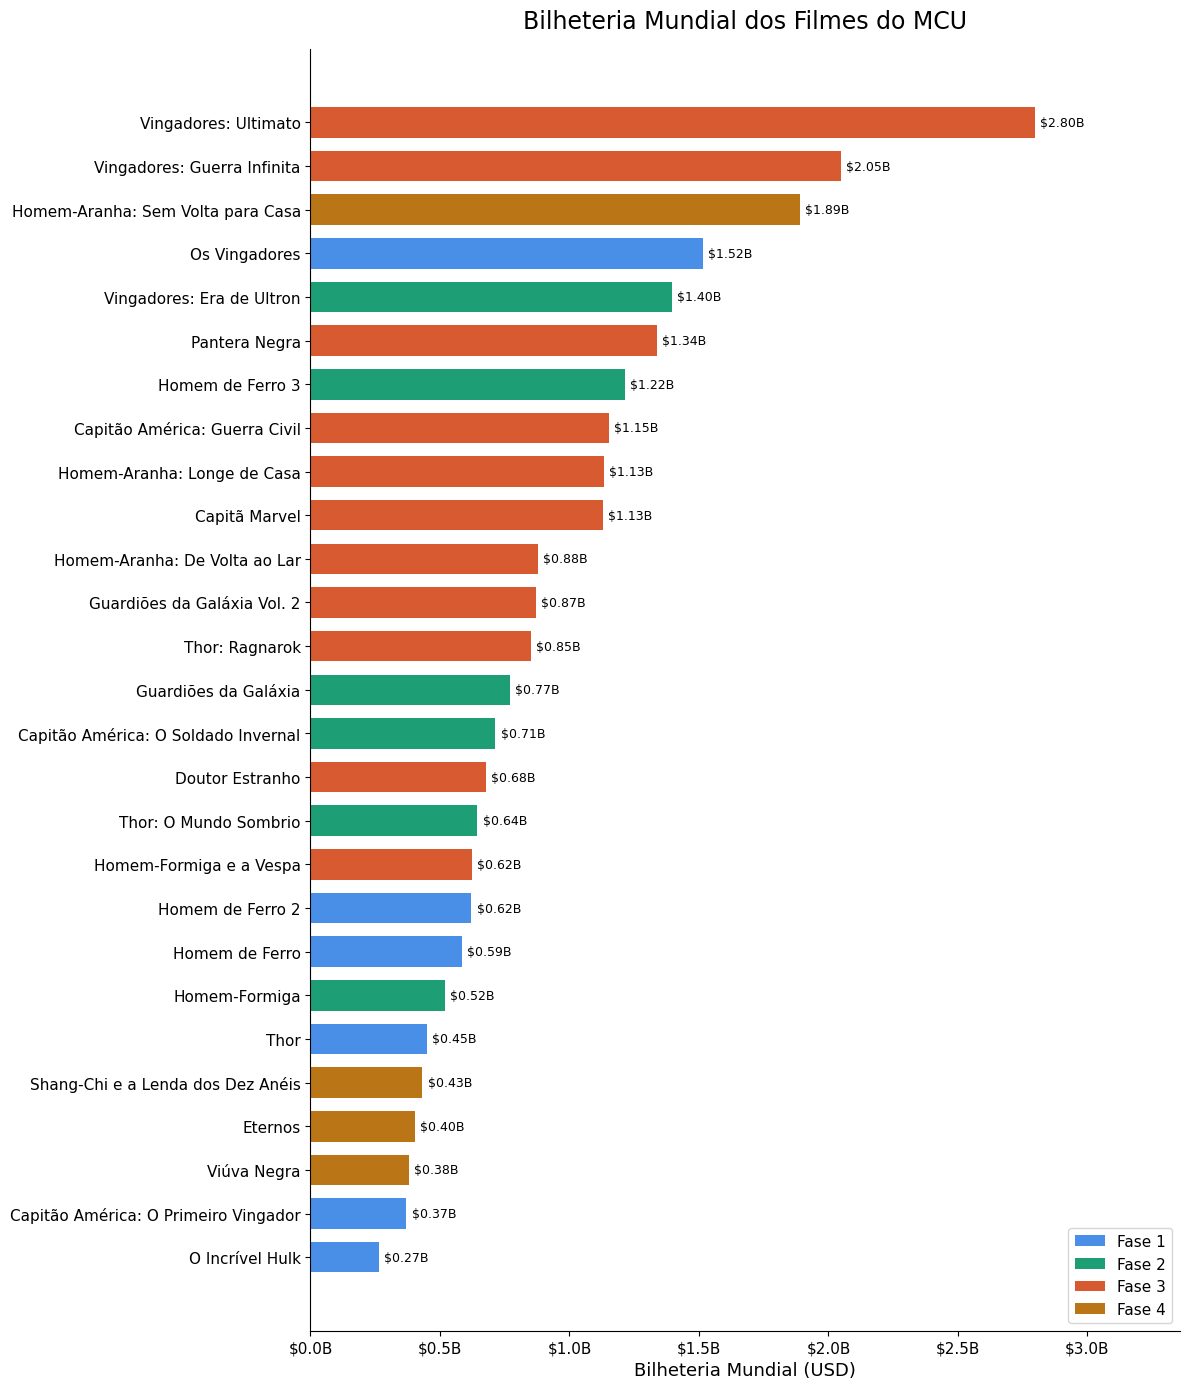

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Criando o gráfico
fig, ax = plt.subplots(figsize=(12, 14))

bars = ax.barh(
    y=filmes_sorted['titulo'],
    width=filmes_sorted['bilheteria_mundial'],
    color=colors,
    edgecolor='none',
    height=0.7
)

# Formatando o eixo X em bilhões
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e9:.1f}B')
)

# Adicionando valores no final de cada barra
for bar in bars:
    valor = bar.get_width()
    ax.text(
        valor + 20_000_000,
        bar.get_y() + bar.get_height() / 2,
        f'${valor/1e9:.2f}B',
        va='center', ha='left', fontsize=9
    )

# Legenda de fases
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4a8fe7', label='Fase 1'),
    Patch(facecolor='#1d9e75', label='Fase 2'),
    Patch(facecolor='#d85a30', label='Fase 3'),
    Patch(facecolor='#ba7517', label='Fase 4'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

# Estilo
ax.set_xlabel('Bilheteria Mundial (USD)', fontsize=13)
ax.set_title('Bilheteria Mundial dos Filmes do MCU', fontsize=17, pad=15)
ax.tick_params(labelsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, filmes_sorted['bilheteria_mundial'].max() * 1.2)

plt.tight_layout()
plt.show()